<a href="https://colab.research.google.com/github/springboardmentor468a/Projects_2/blob/sruthi-mangineni/accuracy_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ==== Cell 1: Imports & Setup ====
import os
import io
import csv
import requests
from PIL import Image, ImageOps
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from torchvision import transforms

OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)
print("Cell 1 ready — outputs folder:", OUTPUT_DIR)


Cell 1 ready — outputs folder: outputs


In [ ]:
# ==== Cell 2: Safe model initialization ====
from torchvision.models.segmentation import (
    deeplabv3_resnet101, DeepLabV3_ResNet101_Weights,
    deeplabv3_mobilenet_v3_large, DeepLabV3_MobileNet_V3_Large_Weights
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

try:
    model = deeplabv3_resnet101(weights=DeepLabV3_ResNet101_Weights.DEFAULT)
    print("Loaded DeepLabV3-ResNet101")
except Exception as e:
    print("ResNet101 failed (OOM or other). Falling back to MobileNetV3. Error:", e)
    model = deeplabv3_mobilenet_v3_large(weights=DeepLabV3_MobileNet_V3_Large_Weights.DEFAULT)
    print("Loaded DeepLabV3-MobileNetV3 fallback")

model.to(device)
model.eval()
print("Cell 2 ready — model is initialized.")


Device: cpu
Downloading: "https://download.pytorch.org/models/deeplabv3_resnet101_coco-586e9e4e.pth" to /root/.cache/torch/hub/checkpoints/deeplabv3_resnet101_coco-586e9e4e.pth


100%|██████████| 233M/233M [00:02<00:00, 101MB/s] 


Loaded DeepLabV3-ResNet101
Cell 2 ready — model is initialized.


In [ ]:
# ==== Cell 3: Preprocessing & utilities ====
preprocess = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

def load_image(src, timeout=20):
    """Load image from HTTP/HTTPS URL or local file path."""
    if isinstance(src, str) and src.startswith("http"):
        resp = requests.get(src, timeout=timeout)
        resp.raise_for_status()
        return Image.open(io.BytesIO(resp.content)).convert("RGB")
    else:
        return Image.open(src).convert("RGB")

def safe_resize(img, max_size=720):
    img2 = img.copy()
    img2.thumbnail((max_size, max_size))
    return img2

def sanitize_name(s):
    bn = os.path.basename(s)
    return "".join(c if c.isalnum() else "_" for c in bn)[:120]

# ---- IMPORTANT: sources list (includes your uploaded local image path) ----
# Developer-provided uploaded image path (used as local source)
LOCAL_UPLOADED_IMAGE = "/mnt/data/WhatsApp Image 2025-11-23 at 21.25.20 (1).jpeg"

# Example sources from different domains
sources = [
    LOCAL_UPLOADED_IMAGE,
    "https://images.unsplash.com/photo-1529626455594-4ff0802cfb7e?format=jpg",  # people
    "https://images.unsplash.com/photo-1524504388940-b1c1722653e1?format=jpg",  # people
    "https://images.unsplash.com/photo-1494790108377-be9c29b29330?format=jpg",  # people
    "https://images.unsplash.com/photo-1518717758536-85ae29035b6d?format=jpg",  # animal
    "https://images.unsplash.com/photo-1503376780353-7e6692767b70?format=jpg",  # car
    "https://images.unsplash.com/photo-1501785888041-af3ef285b470?format=jpg",  # nature
    "https://images.unsplash.com/photo-1550547660-d9450f859349?format=jpg",  # food
    "https://images.unsplash.com/photo-1501594907352-04cda38ebc29?format=jpg",  # building
    "https://images.unsplash.com/photo-1518770660439-4636190af475?format=jpg"   # technology
]

# ---- Ground-truth mask paths (real accuracy requires these).
# Provide one entry per source: either a path/URL to the GT mask image or None to skip accuracy.
# Example placeholders (you must replace these with actual GT masks for real accuracy)
gt_paths = [
    None,  # for your uploaded image - replace with local GT path if you have it
    None,
    None,
    None,
    None,
    None,
    None,
    None,
    None,
    None
]

print("Cell 3 ready: sources and gt_paths initialized. Edit gt_paths to include ground-truth masks for accuracy.")


Cell 3 ready: sources and gt_paths initialized. Edit gt_paths to include ground-truth masks for accuracy.


In [ ]:
# ==== Cell 4: Core segmentation, saving, metrics ====

def get_segmentation_mask(img, max_size=720):
    """Return integer mask (H, W) and resized image (PIL)"""
    img_small = safe_resize(img, max_size=max_size)
    tensor = preprocess(img_small).unsqueeze(0).to(device)
    with torch.no_grad():
        out = model(tensor)["out"]  # N x C x H' x W'
    logits = F.interpolate(out, size=(img_small.height, img_small.width),
                           mode="bilinear", align_corners=False)
    mask = logits.argmax(1).squeeze(0).cpu().numpy().astype(np.int32)  # (H,W)
    return mask, img_small

def mask_to_bw(mask):
    """
    Convert any mask array/tensor to a (H,W) black&white PIL image (mode 'L'),
    where foreground = 255 and background = 0.
    Supports shapes: (H,W), (1,H,W), (C,H,W), (1,1,H,W), etc.
    """
    arr = np.array(mask)
    # Collapse channels/batch by selecting first meaningful 2D slice
    if arr.ndim == 2:
        m2 = arr
    elif arr.ndim == 3:
        # if (C,H,W) or (1,H,W) -> take first channel
        m2 = arr[0]
    elif arr.ndim == 4:
        # (N, C, H, W) -> take first batch, first channel
        m2 = arr[0, 0]
    else:
        raise ValueError(f"Unsupported mask shape: {arr.shape}")
    bw = (m2 > 0).astype(np.uint8) * 255
    return Image.fromarray(bw.astype(np.uint8), "L")

def save_mask_bw(mask, name):
    bw_img = mask_to_bw(mask)
    path = os.path.join(OUTPUT_DIR, f"{name}_mask_bw.png")
    bw_img.save(path)
    return path

def save_isolated(img, mask, name):
    # Ensure mask 2D and same spatial size as img after resize
    arr_mask = np.array(mask)
    if arr_mask.ndim > 2:
        arr_mask = arr_mask[0]
    h, w = arr_mask.shape
    base = img.resize((w, h)).convert("RGBA")
    alpha = Image.fromarray(((arr_mask > 0).astype(np.uint8) * 255).astype(np.uint8))
    base.putalpha(alpha)
    path = os.path.join(OUTPUT_DIR, f"{name}_isolated.png")
    base.save(path)
    return path

def save_overlay(img, mask, name, alpha=0.5):
    arr_mask = np.array(mask)
    if arr_mask.ndim > 2:
        arr_mask = arr_mask[0]
    base = img.convert("RGBA")
    mask_img = Image.fromarray(((arr_mask > 0).astype(np.uint8) * 255).astype(np.uint8)).resize(base.size)
    overlay_layer = Image.new("RGBA", base.size, (255, 0, 0, int(255*alpha)))
    base.paste(overlay_layer, (0,0), mask_img)
    path = os.path.join(OUTPUT_DIR, f"{name}_overlay.png")
    base.save(path)
    return path

def compute_iou_and_acc(pred_mask, gt_mask):
    p = np.array(pred_mask)
    g = np.array(gt_mask)
    # normalize shapes -> convert to 2D bool arrays
    if p.ndim > 2:
        p = p[0]
    if g.ndim > 2:
        g = g[...,0] if g.shape[-1] == 1 else g[0]
    pbin = (p > 0)
    gbin = (g > 127)
    inter = np.logical_and(pbin, gbin).sum()
    union = np.logical_or(pbin, gbin).sum()
    iou = inter / union if union > 0 else float("nan")
    acc = (pbin == gbin).sum() / pbin.size
    return iou, acc

def save_metrics_csv(metrics, csv_name="metrics_summary.csv"):
    csv_path = os.path.join(OUTPUT_DIR, csv_name)
    keys = ["src","mask_bw","isolated","overlay","iou","pixel_acc"]
    with open(csv_path, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=keys)
        writer.writeheader()
        for row in metrics:
            writer.writerow({k: row.get(k, "") for k in keys})
    return csv_path

print("Cell 4 ready — segmentation & utility functions available.")


Cell 4 ready — segmentation & utility functions available.



Processing [0] /mnt/data/WhatsApp Image 2025-11-23 at 21.25.20 (1).jpeg
Failed to load /mnt/data/WhatsApp Image 2025-11-23 at 21.25.20 (1).jpeg: [Errno 2] No such file or directory: '/mnt/data/WhatsApp Image 2025-11-23 at 21.25.20 (1).jpeg'

Processing [1] https://images.unsplash.com/photo-1529626455594-4ff0802cfb7e?format=jpg


/tmp/ipython-input-2760687024.py:33: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(bw.astype(np.uint8), "L")


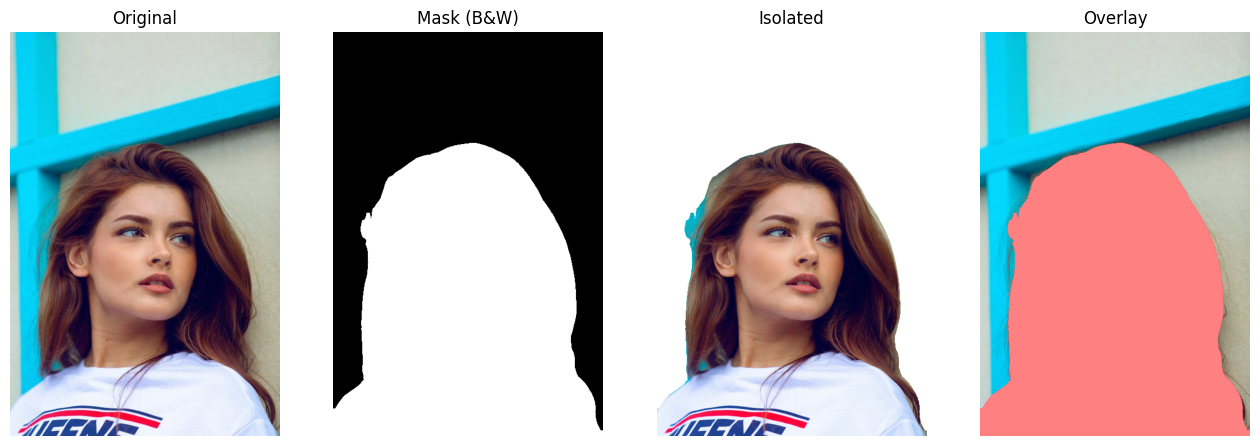


Processing [2] https://images.unsplash.com/photo-1524504388940-b1c1722653e1?format=jpg


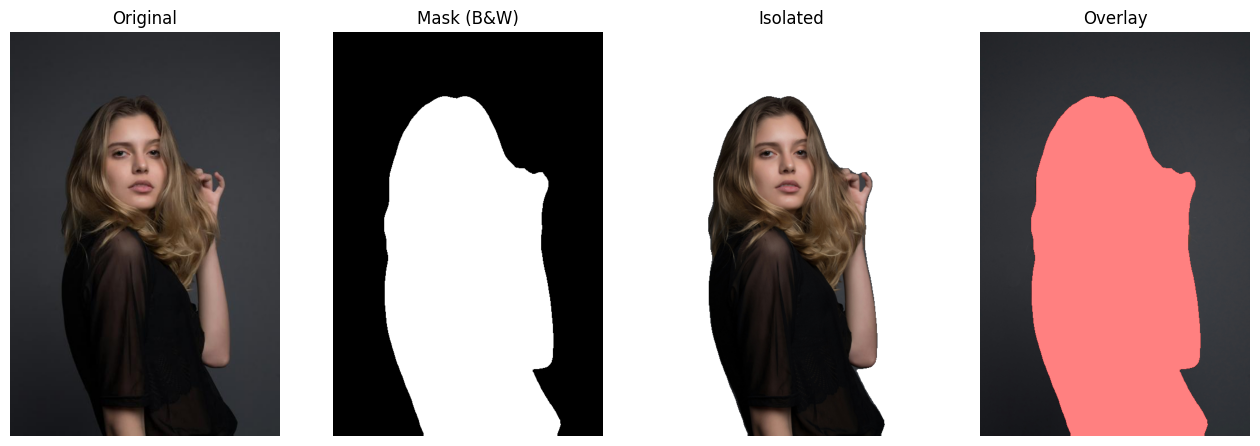


Processing [3] https://images.unsplash.com/photo-1494790108377-be9c29b29330?format=jpg


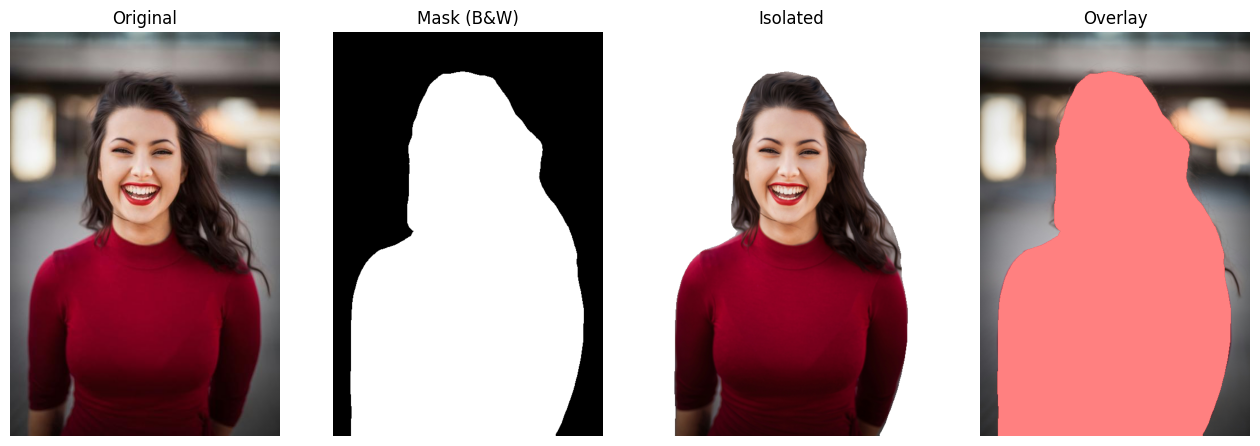


Processing [4] https://images.unsplash.com/photo-1518717758536-85ae29035b6d?format=jpg


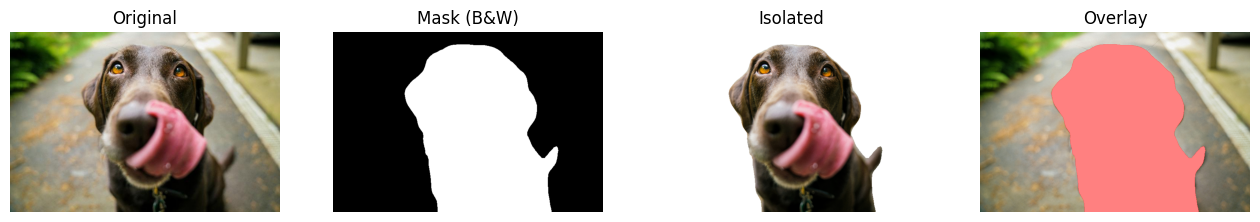


Processing [5] https://images.unsplash.com/photo-1503376780353-7e6692767b70?format=jpg


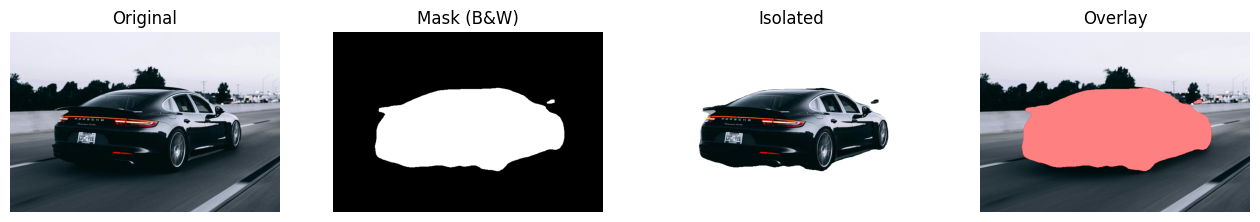


Processing [6] https://images.unsplash.com/photo-1501785888041-af3ef285b470?format=jpg


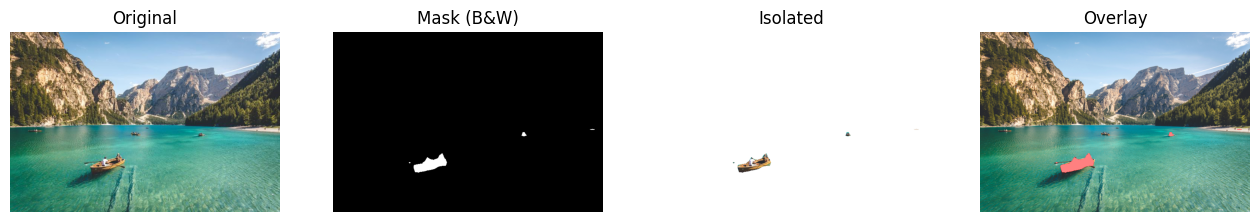


Processing [7] https://images.unsplash.com/photo-1550547660-d9450f859349?format=jpg


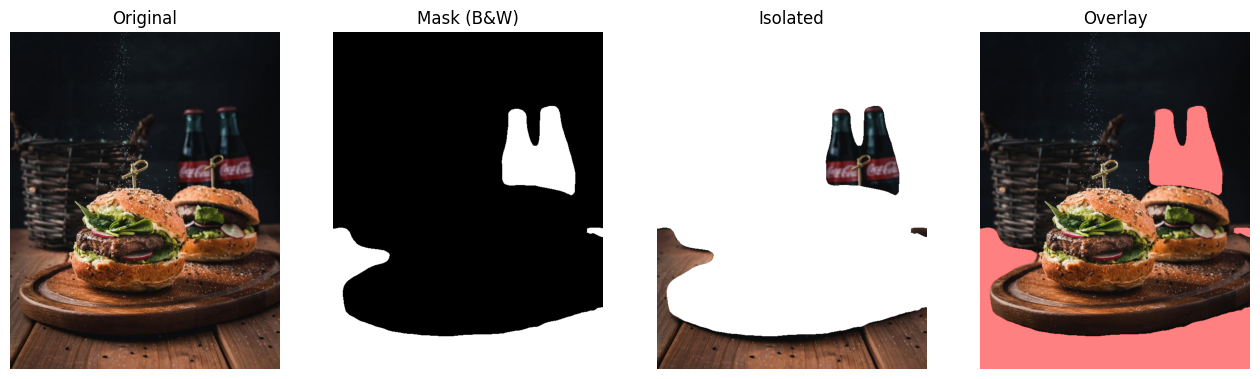


Processing [8] https://images.unsplash.com/photo-1501594907352-04cda38ebc29?format=jpg


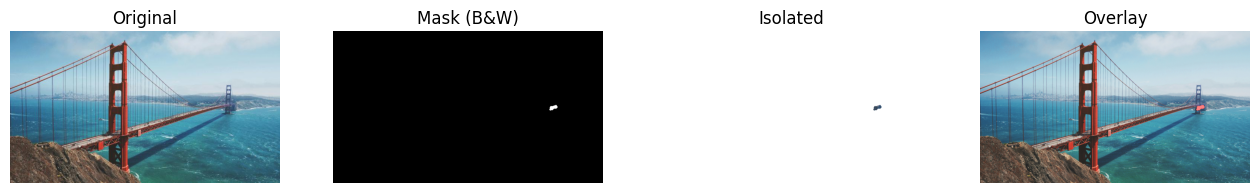


Processing [9] https://images.unsplash.com/photo-1518770660439-4636190af475?format=jpg


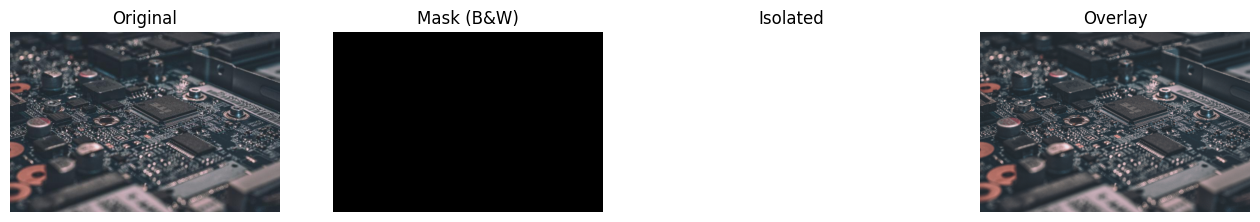


Done. Outputs saved to: outputs
Metrics CSV: outputs/metrics_summary.csv


In [ ]:
# ==== Cell 5: Run, visualize, and compute accuracy ====
results = []

for i, src in enumerate(sources):
    print(f"\nProcessing [{i}] {src}")
    try:
        img = load_image(src)
    except Exception as e:
        print(f"Failed to load {src}: {e}")
        continue

    try:
        mask, img_small = get_segmentation_mask(img)
    except Exception as e:
        print(f"Segmentation failed for {src}: {e}")
        continue

    name = sanitize_name(src) + f"_{i}"

    # Save outputs
    mask_bw_path = save_mask_bw(mask, name)
    isolated_path = save_isolated(img_small, mask, name)
    overlay_path = save_overlay(img_small, mask, name, alpha=0.5)
    orig_path = os.path.join(OUTPUT_DIR, f"{name}_orig.jpg")
    img_small.save(orig_path)

    row = {"src": src, "mask_bw": mask_bw_path, "isolated": isolated_path, "overlay": overlay_path, "iou": "", "pixel_acc": ""}

    # Compute accuracy if GT provided
    gt = None
    if i < len(gt_paths) and gt_paths[i]:
        try:
            gt_img = load_image(gt_paths[i])
            # ensure same size as prediction
            gt_img_resized = gt_img.convert("L").resize(img_small.size)
            iou, acc = compute_iou_and_acc(mask, np.array(gt_img_resized))
            row["iou"] = float(iou) if not np.isnan(iou) else ""
            row["pixel_acc"] = float(acc)
            print(f"IoU: {row['iou']:.4f}, Pixel Acc: {row['pixel_acc']:.4f}")
        except Exception as e:
            print(f"Failed to compute metrics for {src} with GT {gt_paths[i]}: {e}")

    results.append(row)

    # Display 4-panel
    try:
        fig, axes = plt.subplots(1, 4, figsize=(16, 6))
        axes[0].imshow(Image.open(orig_path))
        axes[0].set_title("Original")
        axes[1].imshow(Image.open(mask_bw_path), cmap="gray")
        axes[1].set_title("Mask (B&W)")
        axes[2].imshow(Image.open(isolated_path))
        axes[2].set_title("Isolated")
        axes[3].imshow(Image.open(overlay_path))
        axes[3].set_title("Overlay")
        for ax in axes:
            ax.axis("off")
        plt.show()
    except Exception as e:
        print("Visualization failed:", e)

# Save CSV metrics
csv_path = save_metrics_csv(results)
print("\nDone. Outputs saved to:", OUTPUT_DIR)
print("Metrics CSV:", csv_path)
